In [65]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv


In [66]:
import torch
import numpy as np

print(f"PyTorch Version: {torch.__version__}")

# 1. The Divine Fire: Checking if the GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

print("\n--- NumPy vs PyTorch Practice ---")

# 2. Creating a 2D array in NumPy (something you know)
np_array = np.array([[1.0, 2.0], [3.0, 4.0]])
print(f"NumPy Array:\n{np_array} (Type: {type(np_array)})")

# 3. Forging a PyTorch Tensor from that NumPy array
py_tensor = torch.from_numpy(np_array)
print(f"PyTorch Tensor:\n{py_tensor} (Type: {type(py_tensor)})")

# 4. Sending your tensor to the GPU warrior
if torch.cuda.is_available():
    gpu_tensor = py_tensor.to(device)
    print(f"\nTensor successfully sent to GPU! Device property: {gpu_tensor.device}")

PyTorch Version: 2.10.0+cu128
Using device: cuda
GPU Model: Tesla T4

--- NumPy vs PyTorch Practice ---
NumPy Array:
[[1. 2.]
 [3. 4.]] (Type: <class 'numpy.ndarray'>)
PyTorch Tensor:
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64) (Type: <class 'torch.Tensor'>)

Tensor successfully sent to GPU! Device property: cuda:0


# TESTING FOR GPU

In [67]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

dataset_path = '/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv'
df = pd.read_csv(dataset_path)

df = df.drop(columns=['Date Time'], errors='ignore')
# np.arange(len(df)) // 6 creates groups like: 0,0,0,0,0,0, 1,1,1,1,1,1, 2,2...
#down sampled and didn't sample
df_hour_mean = df.groupby(np.arange(len(df)) // 6).mean()

# we drop'Date Time' string column
features = df_hour_mean[['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']].values

#80 percent for training and 20 percent for testing
split_idx_raw = int(len(features) * 0.8)
train_features = features[:split_idx_raw]
test_features = features[split_idx_raw:]

# Fit scaler only on training data, then transform both
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_features)
test_scaled = scaler.transform(test_features)

#recombining vertically so the sliding window loop works perfectly
features_scaled = np.vstack((train_scaled, test_scaled))

# IMPORTING THE JENA CLIMATE DATASET

In [68]:
X = []
y = []

seq_length = 72
forecast_offset = 12
temp_index = 1 # 'T (degC)' is at index 1 in our features list

print("sliding windows")

for i in range(len(features_scaled) - seq_length - forecast_offset):
    # The 72 hour input sequence of 14 features
    window = features_scaled[i : i + seq_length]
    
    target = features[i + seq_length + forecast_offset - 1, temp_index]
   
    
    X.append(window)
    y.append(target)

#lists to tensors
X_tensor = torch.tensor(np.array(X), dtype=torch.float32)
y_tensor = torch.tensor(np.array(y), dtype=torch.float32)

print(f"Total Number Sequences : {len(X_tensor)}")
print(f"Shape of X_tensor: {X_tensor.shape} -> [Batches, Sequence Length, Features]")

sliding windows
Total Number Sequences : 70008
Shape of X_tensor: torch.Size([70008, 72, 14]) -> [Batches, Sequence Length, Features]


# Preparing the Sliding Window

In [69]:
class JenaDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
        
    def __len__(self):
        return len(self.sequences)
        
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

#we split the data chronologically and seperate test and train set (80% goes for training and 20% goes for testing in chronological order)

split_idx = int(len(X_tensor) * 0.8)

train_dataset = JenaDataset(X_tensor[:split_idx], y_tensor[:split_idx])
test_dataset = JenaDataset(X_tensor[split_idx:], y_tensor[split_idx:])

#dataloaders
#batch size 256 is ok for 1D tensors
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

#verification
sequences, labels = next(iter(train_loader))
print(f"First Batch X shape: {sequences.shape}")
print(f"First Batch Y shape: {labels.shape}")
print(sequences[0][0])#will have 14 elements in the tensor 

First Batch X shape: torch.Size([256, 72, 14])
First Batch Y shape: torch.Size([256])
tensor([-2.1312, -0.4542, -0.2814, -0.5169, -0.0987, -0.5818, -0.6534, -0.3509,
        -0.6246, -0.6249, -0.1343,  1.0692,  2.0187,  0.8274])


# Preparing the dataloders

In [70]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, dim, max_len=5000):
        super().__init__()
        # dim is the hidden dimension of model (like 64)
        # max_len is the maximum sequence length we expect (72 hours, but 5000 is standard)

        # Create a long matrix of zeros with  shape [max_len, dim]
        pe = torch.zeros(max_len, dim)
        
        # Create a column vector of positions  [0, 1, 2, ... max_len-1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)#unsqueeze changes the row to coloum so [max_len,1]
        
        # the denominator is calculated (the 10000^(2i/dim) part)
        # we use exponentiation and natural log for numerical stability in PyTorch
        div_term = torch.exp(torch.arange(0, dim, 2).float() * (-math.log(10000.0) / dim))
        
        # applying sin to all even indices
        pe[:, 0::2] = torch.sin(position * div_term)
        
        # applying cos to all odd indices
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # on adding batch dimension the shape becomes [1, max_len, dim]
        pe = pe.unsqueeze(0)
        
        # registering as a buffer so PyTorch saves it with the model, but do not train it
        # positional encoding is a fixed mathematical wave, not weight
        self.register_buffer('pe', pe)

    def forward(self, x):
        #x shape  [Batch_Size, Sequence_Length, dim]
        #We simply ADD our positional waves to the input data
        
        # slicing the positional encoding to match the sequence length of x (for our cilmate data it will be 72)
        x = x + self.pe[:, :x.size(1), :]
        return x

#Testing
dim = 64
seq_length = 72
batch_size = 256

#test data
test_data = torch.zeros(batch_size, seq_length, dim)
positional_encoder = PositionalEncoding(dim=dim)

# Add the timestamps
pos_encoded_data = positional_encoder(test_data)

print(f"Original shape: {test_data.shape}")
print(f"post_Encoded_shape: {pos_encoded_data.shape}")
print("Positional Encoding is successfully")

Original shape: torch.Size([256, 72, 64])
post_Encoded_shape: torch.Size([256, 72, 64])
Positional Encoding is successfully


# Positional Encoding Module

In [71]:
class Transformer_Prime(nn.Module):
    def __init__(self, features=14, dim=64, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()
        
        # Feature Projection Layer
        # the Transformer needs an embedding dimension of 64, but we only have 14 weather features.
        # this linear layer stretches our 14 features into the required 64 dimensions.
        self.feature_projection = nn.Linear(features, dim)
        
        # positional encoding
        self.pos_encoder = PositionalEncoding(dim=dim)
        
        # Transformer Encoder
        # batch_first=True is needed as our data comes in as [Batch, Sequence, Features]
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, 
            nhead=num_heads, 
            dim_feedforward=dim * 4, 
            dropout=dropout, 
            batch_first=True
        )
        # we stack two layers together
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # regression layer
        # takes the output and squashes it into a single temperature prediction
        self.regressor = nn.Linear(dim, 1)

    def forward(self, x):
        # x shape [Batch, 72, 14]
        
        # Step 1: Project features -> Shape becomes [Batch, 72, 64]
        x = self.feature_projection(x)
        
        # Step 2: Add our timestamps
        x = self.pos_encoder(x)
        
        # Step 3: transformer calculates all the attention weights
        x = self.transformer_encoder(x)
        
        # Step 4: we Get the output of the laast hour in the sequence (index -1)
        # We use the final hour's context to predict the future temperature
        last_hour = x[:, -1, :]  # Shape becomes [Batch, 64]
        
        # Step 5: final regression prediction -> Shape becomes [Batch, 1]
        prediction = self.regressor(last_hour)
        
        return prediction

# Test
Test_data = torch.randn(256, 72, 14)

# Initialize the model
test_model = Transformer_Prime()

# data through model
Test_prediction = test_model(Test_data)

print(f"Input shape: {Test_data.shape}")
print(f"Output prediction shape: {Test_prediction.shape}")
print("Transformer Architecture is successfully connected!")

Input shape: torch.Size([256, 72, 14])
Output prediction shape: torch.Size([256, 1])
Transformer Architecture is successfully connected!


# BUILDING THE TRANSFORMER

In [72]:
model_prime=Transformer_Prime().to(device)
print(model_prime)

Transformer_Prime(
  (feature_projection): Linear(in_features=14, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (regressor): Linear(in_features=64, out_features=1, bias=True)
)


--- Beginning of Training (Training the model) ---
  [Epoch 1, Batch 100] Loss(MSE): 146.0664
  [Epoch 1, Batch 200] Loss(MSE): 104.3114
Epoch [1/25] | Train Loss(MSE): 121.8419 | Val Loss: 107.3958
  [Epoch 2, Batch 100] Loss(MSE): 77.2787
  [Epoch 2, Batch 200] Loss(MSE): 67.5021
Epoch [2/25] | Train Loss(MSE): 71.7081 | Val Loss: 83.0449
  [Epoch 3, Batch 100] Loss(MSE): 57.1615
  [Epoch 3, Batch 200] Loss(MSE): 47.4550
Epoch [3/25] | Train Loss(MSE): 51.2155 | Val Loss: 53.4521
  [Epoch 4, Batch 100] Loss(MSE): 32.2178
  [Epoch 4, Batch 200] Loss(MSE): 22.0240
Epoch [4/25] | Train Loss(MSE): 26.2081 | Val Loss: 22.2700
  [Epoch 5, Batch 100] Loss(MSE): 12.8826
  [Epoch 5, Batch 200] Loss(MSE): 8.9033
Epoch [5/25] | Train Loss(MSE): 10.6165 | Val Loss: 10.8343
  [Epoch 6, Batch 100] Loss(MSE): 7.1918
  [Epoch 6, Batch 200] Loss(MSE): 6.5790
Epoch [6/25] | Train Loss(MSE): 6.8435 | Val Loss: 8.4119
  [Epoch 7, Batch 100] Loss(MSE): 6.1501
  [Epoch 7, Batch 200] Loss(MSE): 6.0040
Epoc

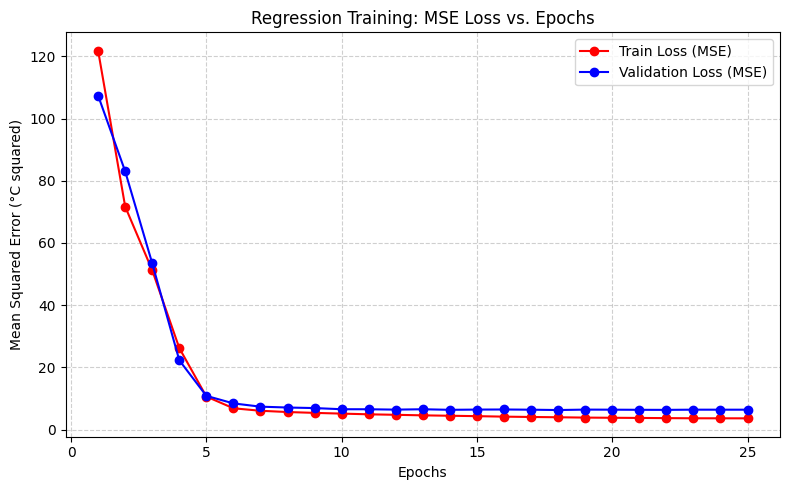

In [73]:
#  Baseline Training
import torch.optim as optim
import matplotlib.pyplot as plot
loss_history=[]
val_loss_history = []
batch_loss_history=[]

# 1.Loss Function and Optimizer

criterion = nn.MSELoss()
# Adam is a highly efficient optimizer that dynamically adjusts the learning rate
optimizer = optim.Adam(model_prime.parameters(), lr=0.0005)#lr=learning rate
epochs=25
# factor=0.5 means cut Learning rate in half. patience=2 means wait 2 epochs of no improvement before cutting.
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

#this is a standard scheduler for transformer
# high learning rate right out of the gate, the gradients can explode, and the loss might immediately jump to NaN (infinity), completely crashing the model.

scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.0005, epochs=epochs, steps_per_epoch=len(train_loader))
#the Transformer scheduler does the exact opposite of what you would expect: it starts the learning rate at almost zero.
#Once the learning rate reaches its maximum peak, the scheduler enters the decay phase. It slowly and smoothly curves the learning rate back down toward zero for the remainder of the training (usually following the mathematical curve of a cosine wave)

# 2.Training Loop

#An Epoch is one complete pass through the entire library
epochs=25
print("--- Beginning of Training (Training the model) ---")
for epoch in range(epochs):
    model_prime.train() # Set the model to training mode
    running_loss = 0.0
    running_batch_loss=0.0
    
    for i, (inputs, labels) in enumerate(train_loader):#batch numbers,images,answers
        # Moving the batched data to  GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # Step 1: Clear the old gradients from the last step
        optimizer.zero_grad()

        # Step 2: forward pass (make blind guess)
        outputs = model_prime(inputs)
        
        # Step 3: Calculate the loss (How wrong was the prediction?)
        loss = criterion(outputs.squeeze(), labels.float())

        # Step 4: Backward Pass (Calculate the gradients),backpropagation
        loss.backward()

        # Step 5: Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model_prime.parameters(), max_norm=1.0)
        #This acts as a strict mathematical speed limit and prevents massive spikes in the gradients from destabilizing the transformer

        # Step 6: Optimize (Update the models weights)
        optimizer.step()

        scheduler.step()

        running_loss += loss.item()
        running_batch_loss += loss.item()
        # Jena Climate dataset has roughly 420,000 ,we divided into hours so by 6 which is 70,000
        #80 percent of 70,000 is y 56,000
        #56,000 by 256(batch_size) which is approx 218(when floored)
        if i % 100 == 99:
            print(f"  [Epoch {epoch + 1}, Batch {i + 1}] Loss(MSE): {running_batch_loss / 100:.4f}")
            batch_loss_history.append(running_batch_loss / 100)
            running_batch_loss = 0.0


    # calculating average loss for the epoch
    epoch_train_loss = running_loss / len(train_loader)
    
    loss_history.append(epoch_train_loss)


# --- VALIDATION PHASE ---
    model_prime.eval() # Set model to evaluation mode 
    running_val_loss = 0.0
    
    # torch.no_grad() disables gradient calculation to save memory and compute
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_prime(inputs)
            loss = criterion(outputs.squeeze(), labels.float())
            
            running_val_loss += loss.item()
            
    
            
    epoch_val_loss = running_val_loss / len(test_loader)
    val_loss_history.append(epoch_val_loss)
    # scheduler.step(epoch_val_loss)
    
    # Print metrics for the epoch
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss(MSE): {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}")

            

print("--- Training Completed ---")

# 3. Plotting Results against Epochs
epochs_range = range(1, epochs + 1)

plot.figure(figsize=(8, 5))
plot.plot(epochs_range, loss_history, label='Train Loss (MSE)', color='red', marker='o')
plot.plot(epochs_range, val_loss_history, label='Validation Loss (MSE)', color='blue', marker='o')
plot.title('Regression Training: MSE Loss vs. Epochs')
plot.xlabel('Epochs')
plot.ylabel('Mean Squared Error (°C squared)')
plot.legend()
plot.grid(True, linestyle='--', alpha=0.6)

plot.tight_layout()
plot.show()

# Validation and Train Loss Curves

--- Running Final Evaluation ---

--- Final Regression Metrics ---
Mean Squared Error (MSE):  6.3798
Mean Absolute Error (MAE): 1.9391 °C
Huber Loss:                1.4969


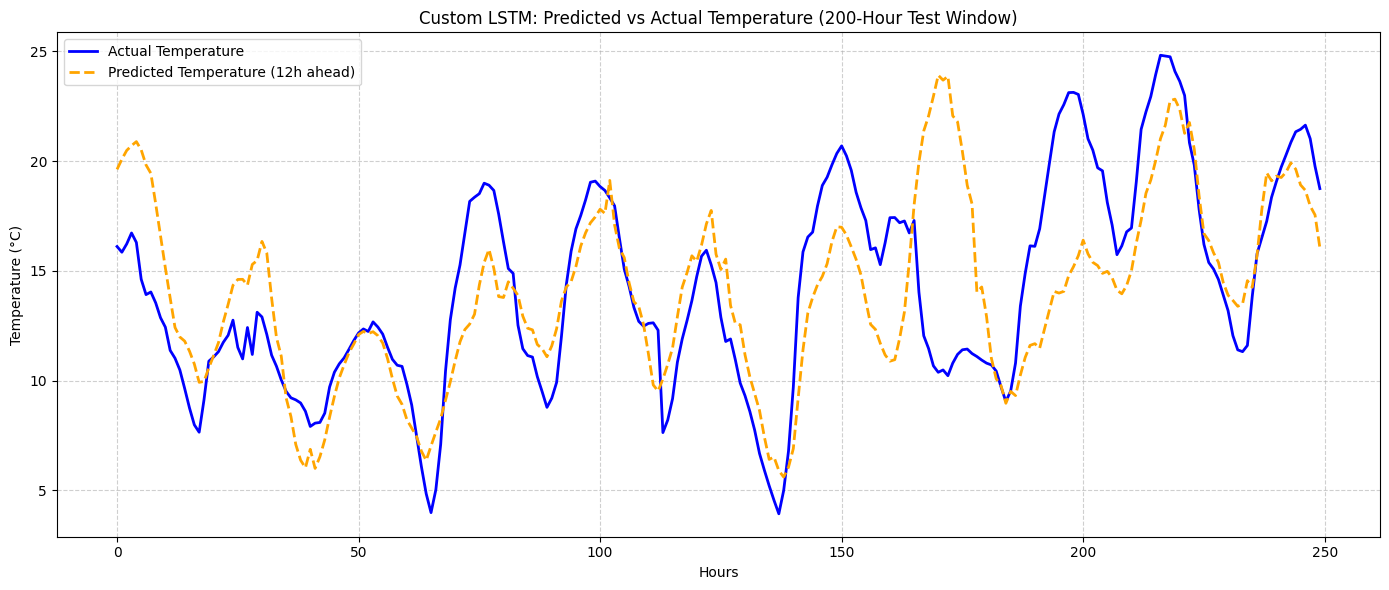

In [74]:
import torch.nn.functional as F
import torch

# 1. Setup for Evaluation
model_prime.eval()
all_predictions = []
all_actuals = []

print("--- Running Final Evaluation ---")

# 2. Collect all predictions and actual targets from the test set
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        
        # Squeeze outputs to make them 1D, just like the labels
        outputs = model_prime(inputs).squeeze() 
        
        # Move back to CPU and convert to lists for metric calculation
        all_predictions.extend(outputs.cpu().numpy())
        all_actuals.extend(labels.cpu().numpy())

# Convert lists to PyTorch tensors for PyTorch's built-in loss functions
preds_tensor = torch.tensor(all_predictions)
actuals_tensor = torch.tensor(all_actuals)

# 3. Calculate Final Mentor-Requested Metrics
mse = F.mse_loss(preds_tensor, actuals_tensor)
mae = F.l1_loss(preds_tensor, actuals_tensor)
huber = F.huber_loss(preds_tensor, actuals_tensor)

print("\n--- Final Regression Metrics ---")
print(f"Mean Squared Error (MSE):  {mse.item():.4f}")
print(f"Mean Absolute Error (MAE): {mae.item():.4f} °C")
print(f"Huber Loss:                {huber.item():.4f}")

# 4. Generate the Single Comparison Plot
# We'll plot a 200-hour window from the test set to get a clear view of the curves
window_size = 250 

plot.figure(figsize=(14, 6))
plot.plot(all_actuals[:window_size], label='Actual Temperature', color='blue', linewidth=2)
plot.plot(all_predictions[:window_size], label='Predicted Temperature (12h ahead)', color='orange', linestyle='dashed', linewidth=2)

plot.title('Custom LSTM: Predicted vs Actual Temperature (200-Hour Test Window)')
plot.xlabel('Hours')
plot.ylabel('Temperature (°C)')
plot.legend()
plot.grid(True, linestyle='--', alpha=0.6)
plot.tight_layout()
plot.show()

# Prediction vs Actual Comparision

In [75]:
torch.save(model_prime.state_dict(), '/kaggle/working/Transformer_weights.pth')
print("Model weights saved successfully to /kaggle/working/Transformer_weights.pth!")

Model weights saved successfully to /kaggle/working/Transformer_weights.pth!


# Saving Model Weights